# Gene expression clustering

**Goal:**
Cluster gene expression. Identify clusters of genes with similar profiles of activation or repression.

**Simple Procedure:**
1. Align peaks of gene expression
2. Then cluster.
3. Visualize expression of clusters to identify patterns of similar activation.
4. Visualize the chromatin of the activation, and repression timepoints.

**More complex**
1. Compute a distance matrix
2. For every pair of entries, compute a correlation score by sliding the vector down each timepoint. The value of the distance will be the translation the outcome the maximal correlation.

**Expected outcome:**
There may be some similar patterns among similarly activated genes. For example, a gene that rapidly activates may exhibit a stronger change in nucleosome shift than a gene that gradually turns on.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.Figure3_Chrom_Gene_Expression import Figure3_Chrom_GeneExpression
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
figures = Figure3_Chrom_GeneExpression(outdir)

In [5]:
gene_expression = figures.gene_expression_a.gene_expression_f

In [25]:
normalized_gene_expression = gene_expression / gene_expression.sum(axis=1).values.reshape((-1, 1))
normalized_gene_expression.head(2)

,0,1,2,3,4,5,6,7,8,9,...,168,169,170,171,172,173,174,175,176,177
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067W-A,0.005667,0.005667,0.005666,0.005666,0.005666,0.005666,0.005666,0.005665,0.005665,0.005665,...,0.005615,0.005615,0.005615,0.005615,0.005615,0.005615,0.005615,0.005615,0.005614,0.00514
YAL067C,0.01109,0.010965,0.010725,0.010361,0.009891,0.009394,0.008888,0.008392,0.007921,0.007444,...,0.004159,0.004097,0.004031,0.003964,0.003892,0.003817,0.003783,0.003799,0.003829,0.007967


In [53]:
max_indices = normalized_gene_expression.values.argmax(axis=1)

# Rotate each vector such that the maximal index lies on the 50th index position
rotated_expression = normalized_gene_expression.copy()
for i in range(len(normalized_gene_expression)):
    gene_row = normalized_gene_expression.iloc[i]
    max_index = max_indices[i]
    
    def rotate_vector(vector, translation):
        rotated_vector = np.concatenate([vector[translation:], vector[:translation]])
        return rotated_vector
    
    rotated_gen_row = rotate_vector(gene_row.values, max_index)
    rotated_expression.iloc[i, :] = rotated_gen_row

    if i == 1:
        break

In [62]:
from src.config import load_configs_by_config_type

config1, config2 = load_configs_by_config_type('shared')
t_indices = config1.get_Hpositions_for_branch('t')
gene_expression_top_branch = gene_expression[t_indices]


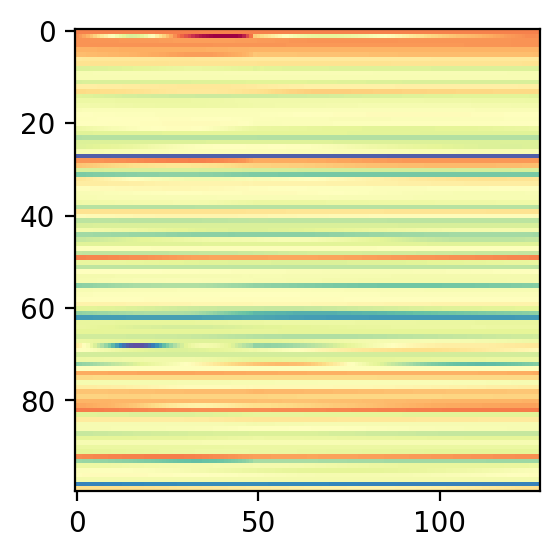

In [134]:
fig = plt.figure(figsize=(3, 3))
plt.imshow(gene_expression_top_branch.astype(float).iloc[0:100], 
    aspect='auto', interpolation='none', cmap='Spectral')


In [139]:
from src.peak_to_trough import compute_quantile_ptr_2d

top_gene_expression_ptr = compute_quantile_ptr_2d(gene_expression_top_branch, hi=0.9, lo=0.1)
top_gene_expression_ptr_df = gene_expression_top_branch[[]].copy()
top_gene_expression_ptr_df['ptr'] = top_gene_expression_ptr

In [456]:
# Select a set of genes in the upper 99% percentile
q = 0.95
q_val = np.quantile(top_gene_expression_ptr_df, q)
quantile_ptr_genes = top_gene_expression_ptr_df[top_gene_expression_ptr_df.ptr > q_val]
print(f"Selected {len(quantile_ptr_genes)} genes in the top 80% with quantile value greater"
      f" than {q_val:.2f}")

Selected 279 genes in the top 80% with quantile value greater than 1.33


0

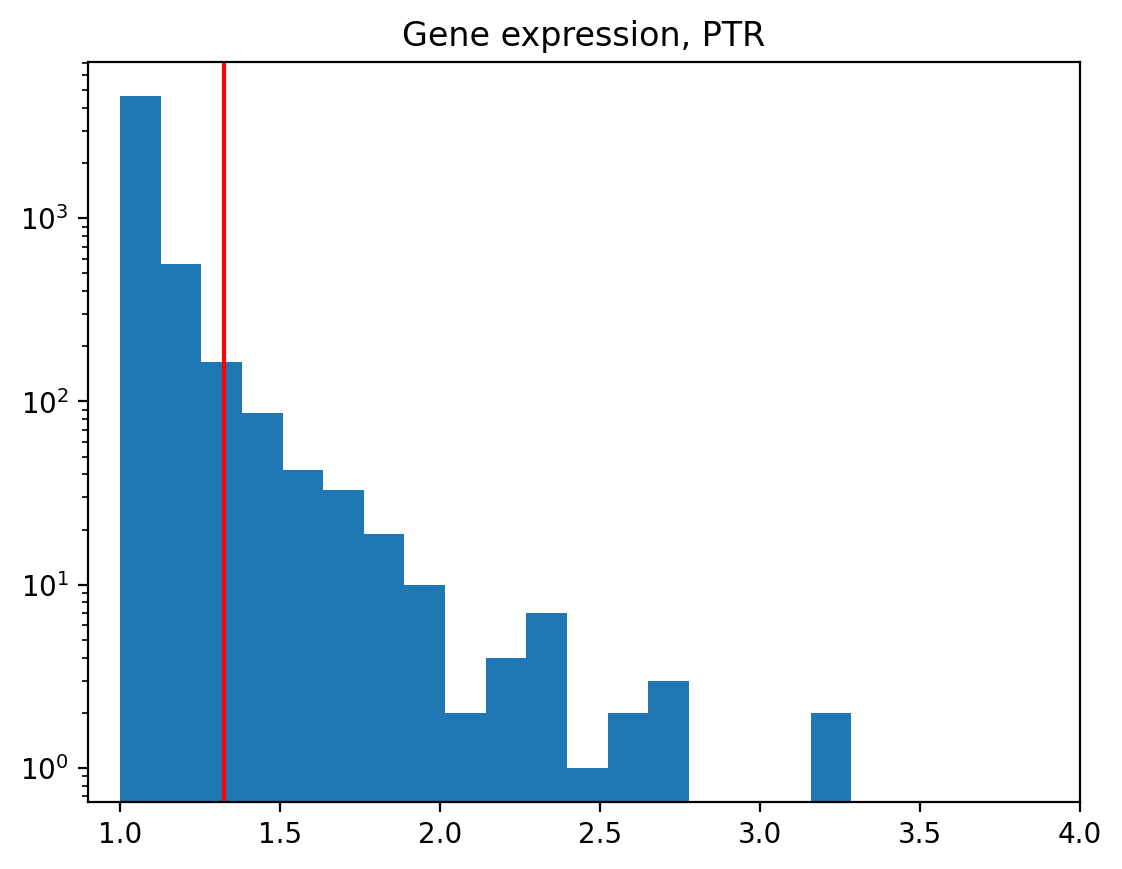

In [457]:
plt.hist(top_gene_expression_ptr_df, bins=100)
plt.yscale('log')
plt.xlim(0.9, 4)
plt.axvline(q_val, c='red')
plt.title("Gene expression, PTR")
0

In [458]:
high_ptr_gene_expression = gene_expression_top_branch.loc[quantile_ptr_genes.index]

In [483]:
import numpy as np
from scipy.signal import correlate
from sklearn.cluster import DBSCAN
from src.timer import Timer

def circular_correlation(series1, series2):
    """Compute the circular correlation between two time series."""
    series1 = np.array(series1)
    series2 = np.array(series2)
    n = len(series1)
    corr = correlate(series1, series2, mode='full')
    
    # Normalize the cross-correlation to get values between -1 and 1
    norm_factor = np.linalg.norm(series1) * np.linalg.norm(series2)
    circular_corr = np.concatenate([corr[-(n-1):], corr[:n]]) / norm_factor

    return np.max(circular_corr)

def circular_distance(series1, series2):
    """Convert circular correlation to a distance measure."""
    return 1 - circular_correlation(series1, series2)

timer = Timer()

normalized_high_ptr_expression = (high_ptr_gene_expression - \
    high_ptr_gene_expression.mean(axis=1).values.reshape((-1, 1))) /\
    high_ptr_gene_expression.std(axis=1).values.reshape((-1, 1))

time_series_data = normalized_high_ptr_expression.values

# Compute the pairwise distance matrix using circular correlation
n_samples = len(time_series_data)
distance_matrix = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    for j in range(i + 1, n_samples):
        distance = circular_distance(time_series_data[i], time_series_data[j])
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance

In [490]:
# Apply DBSCAN with the precomputed distance matrix
# Maximum distance between two samples to be considered as in the same neighborhood
eps = 0.01
 # Minimum number of samples in a neighborhood for a point to be considered as a core point
min_samples = 2
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
labels = dbscan.fit_predict(distance_matrix)

print("Cluster Labels:")
print(labels)
timer.print_time("Finished. ")

Cluster Labels:
[-1  0  1  2  3 -1  4 -1  5  6  7  4  4  4  6  2 -1  8  1 -1  0  2 -1  9
  1  4 10 11 -1  1 -1 -1  1  2  1 -1 -1  5 12  1  1  1  1  1  5 -1 -1  1
  6  9 -1 10  6  4  6 -1 -1 -1 -1 -1 -1  1  1 13 14 -1 -1  7  1 -1 -1 -1
 -1 15  1 -1 -1 -1 11  5 13 -1  2 -1  1  9  1 -1 -1  2 14  9  5  2 -1  1
  1 15 -1 16  9  2  2 17  1  1 -1 -1 18 13  5  1  1  1  9 15 13  9  1 -1
 -1 -1  7  1  5  8 -1 -1 -1 -1 10 -1  1  9 -1 -1 19 -1  1 14  9 -1 -1 -1
 -1  1  1  1  5 -1 14  1 -1 16 -1 -1 17 -1  1  1 -1 -1 12 -1  5 15  9 -1
 19  1  2 -1  1  1  2 12 -1 -1 18  2 -1 20  5 -1  1 21  2  1  1  9  9  9
  5  9  9 -1 12  2 -1  2  1  1  5 15 -1  2 -1  1 -1 -1  1 -1 15 -1  1  1
  1 -1 14  1  1 -1 13 -1  4  4  4 -1  1 -1 21  1  2  9 -1 -1  1  1  9 -1
 20 -1  0 -1 -1  1  1 -1 -1  1  2  9 -1  5 -1 15  2  1  1  8  1 -1  5  1
  9  4  1 -1 10  3  9  1  1 -1 -1  2 11  1  1]
Finished.  - 00:00:37.390


In [491]:
clustered_exp = high_ptr_gene_expression.copy()
clustered_exp['cluster'] = labels
clustered_exp = clustered_exp.reset_index().set_index(['cluster', 'orf_name'])

# Sort indices by cluster labels (and within clusters by distance)
sorted_indices = np.argsort(labels)

# Rearrange the distance matrix according to sorted indices
sorted_distance_matrix = distance_matrix[sorted_indices, :][:, sorted_indices]

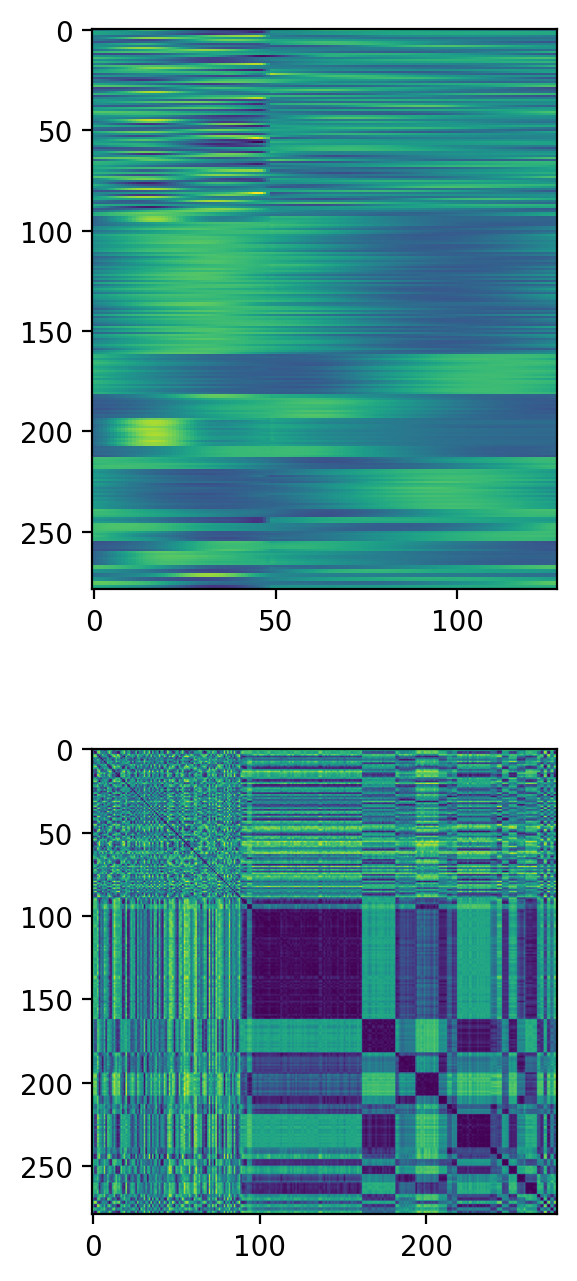

In [493]:
plt.figure(figsize=(3, 8))
plt.subplot(2, 1, 1)
plt.imshow(normalized_high_ptr_expression.iloc[sorted_indices].astype(float), 
    aspect='auto', interpolation='none')

plt.subplot(2, 1, 2)
plt.imshow(sorted_distance_matrix)
